### Mapeando la funcion de probabilidad


\begin{equation}
    p(\widetilde{X}) = p(\widetilde{E})\text{ det }\mathbb{J}_{\varepsilon \widetilde{X}}
\end{equation}

In [146]:
import numpy as np
from Utils import (
    compute_functions, 
    compute_state_vector, 
    Kepler, OrbitTrasformations, 
    compute_jacobian_XoE,
    CanonicalUnits, 
    GravitationalParameters, 
    trasformation_E_to_X, 
    trasformation_X_to_E,
    P_E, 
    P_X_vectorized,
    )
import spiceypy as spy
import scipy.optimize as optimize
from typing import Dict, Set, Optional, Union, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import multimin as mm
import matplotlib.ticker as mticker
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [147]:
cu = CanonicalUnits()
deg = cu.deg
AU_m = cu.AU_m #m
M_sun = cu.M_sun
G = cu.G # m^3 / (kg s^2)
year = cu.year #s
mu = cu.mu
grav_params = GravitationalParameters(mu=mu)

In [148]:
a = np.random.uniform(0, 2)
e = np.random.uniform(0, 1)
i = np.random.uniform(0, np.pi)
Omega = np.random.uniform(0, 2*np.pi)
w = np.random.uniform(0, 2*np.pi)
M = np.random.uniform(0, 2*np.pi)
q = a*(1-e)

print('orbital elements: ', a, e, i, Omega, w, M)

orbital elements:  1.3433432599582555 0.2806417240267939 0.5502927437983117 4.830247564963309 5.316390105412064 3.5646813608258867


In [149]:
x, y, z, vx, vy, vz = trasformation_E_to_X(a, e, i, Omega, w, M, mu)
print('state vector: ', x, y, z, vx, vy, vz)

state vector:  0.7950518952658785 1.3841418874610798 0.5842388204580669 -3.124621502299268 2.0548507380904844 -1.7554451192453069


In [150]:
def P_X_vectorized(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, mu: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    problematic = []
    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
        with np.errstate(divide='ignore', invalid='ignore'):
            det = np.linalg.det(J)
            #print(x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx])
            #print(det)
            if det == 0 or not np.isfinite(det):
                problematic.append((x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx]))
                P.flat[idx] = np.nan
            else:
                inv_det = 1.0/det  
                P.flat[idx] = P_E() * abs(inv_det)

    return P.reshape(shape), problematic


In [151]:
P_X_vectorized(x, y, z, vx, vy, vz, mu)

(array(3.04020139e-05), [])

### Evaluating in the integral limits 

In [152]:
xmin, xmax = (0.9039710143502464, 1.0960289856497536)
ymin, ymax = ( -0.09602898564975362, 0.09602898564975362)
zmin, zmax = (-0.09602898564975362, 0.09602898564975362)
vxmin, vxmax = (-0.5064245183055923, 0.5064245183055923)
vymin, vymax = (5.777598212496408, 6.790447249107593)
vzmin, vzmax = (-0.5064245183055923, 0.5064245183055923)


X = np.linspace(xmin, xmax, 100)
Y = np.linspace(ymin, ymax, 100)
Z = np.linspace(zmin, zmax, 100)
VX = np.linspace(vxmin, vxmax, 100)
VY = np.linspace(vymin, vymax, 100)
VZ = np.linspace(vzmin, vzmax, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla) + 0.1

P_XY, problematic_XY = P_X_vectorized(X_malla, Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_XZ, problematic_XZ = P_X_vectorized(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_VXY, problematic_VXY = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu)
P_VXZ, problematic_VXZ = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu)

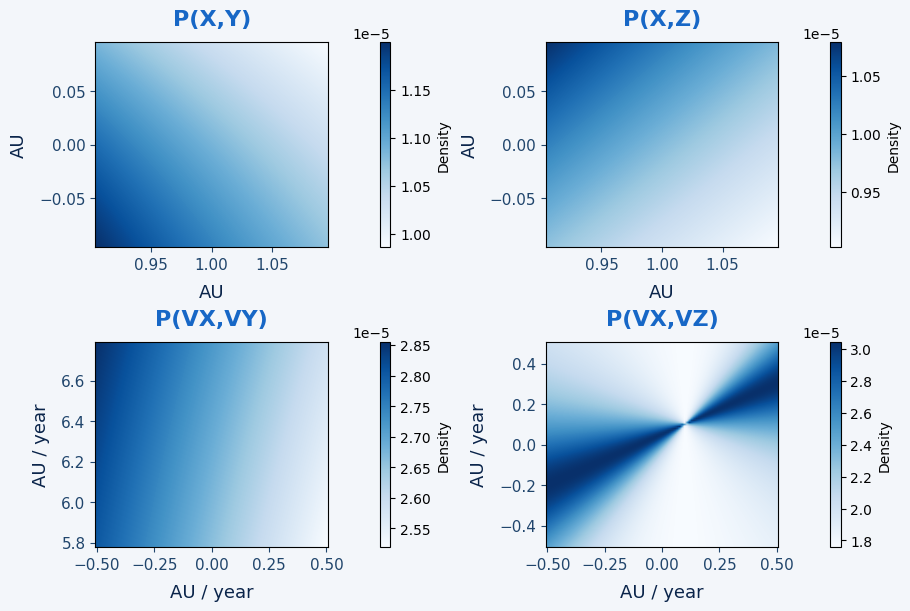

In [153]:
plot_configs = [
    {
        "data": P_XY,
        "extent": [xmin, xmax, ymin, ymax],
        "title": "P(X,Y)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_XZ,
        "extent": [xmin, xmax, zmin, zmax],
        "title": "P(X,Z)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_VXY,
        "extent": [vxmin, vxmax, vymin, vymax],
        "title": "P(VX,VY)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    },
    {
        "data": P_VXZ,
        "extent": [vxmin, vxmax, vzmin, vzmax],
        "title": "P(VX,VZ)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    }
]

# Use 'Blues' colormap and customize plot styling
fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True, facecolor="#f3f6fa")

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        plot_configs[i]["data"],
        origin='lower',
        cmap='Blues',
        interpolation='bilinear',
        extent=plot_configs[i]["extent"],
        aspect='auto'
    )
    ax.set_title(
        plot_configs[i]["title"], 
        fontsize=16, 
        color="#1767c6", 
        pad=12, 
        weight='bold'
    )
    ax.set_xlabel(plot_configs[i]["xlabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.set_ylabel(plot_configs[i]["ylabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=11, colors='#20456c')
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    fig.colorbar(
        im, 
        ax=ax, 
        fraction=0.045, 
        pad=0.04, 
        orientation='vertical', 
        label='Density'
    )
"""
plt.suptitle(
    'Probability Density Function $P(X)$ evaluated at the limits of the distribution state space vectors',
    fontsize=18,
    color='#15335b',
    fontweight='semibold',
    y=1.04
)
"""
plt.show()

In [154]:
xmin, xmax = (-1, 1)
ymin, ymax = ( -1, 1)
zmin, zmax = (-0.2, 0.2)
vxmin, vxmax = (-5, 5)
vymin, vymax = (-5, 5)
vzmin, vzmax = (-0.8, 0.8)

X = np.linspace(xmin, xmax, 100)
Y = np.linspace(ymin, ymax, 100)
Z = np.linspace(zmin, zmax, 100)
VX = np.linspace(vxmin, vxmax, 100)
VY = np.linspace(vymin, vymax, 100)
VZ = np.linspace(vzmin, vzmax, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla) + 0.1

P_XY, problematic_XY = P_X_vectorized(X_malla, Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_XZ, problematic_XZ = P_X_vectorized(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_VXY, problematic_VXY = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu)
P_VXZ, problematic_VXZ = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu)

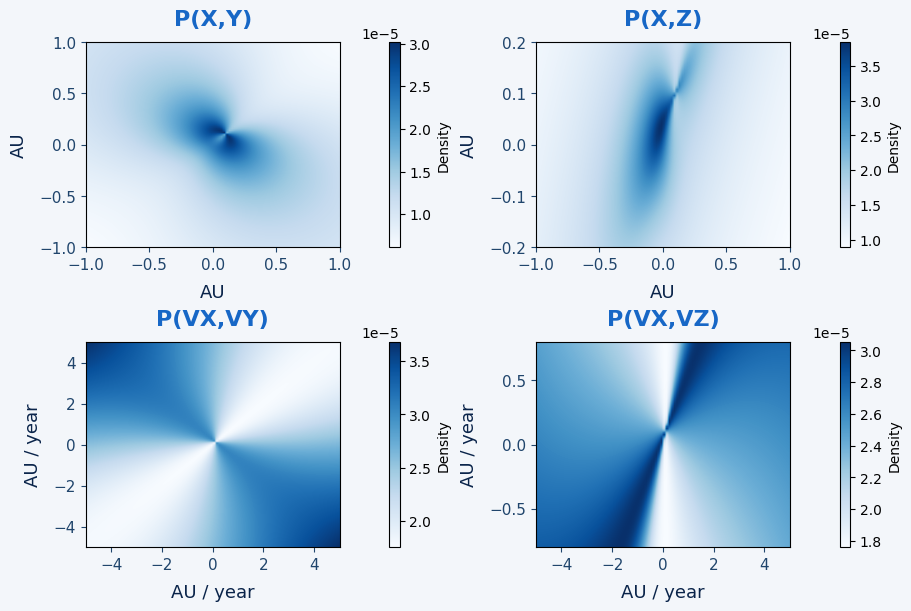

In [155]:
# Use 'Blues' colormap and customize plot styling
plot_configs = [
    {
        "data": P_XY,
        "extent": [xmin, xmax, ymin, ymax],
        "title": "P(X,Y)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_XZ,
        "extent": [xmin, xmax, zmin, zmax],
        "title": "P(X,Z)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_VXY,
        "extent": [vxmin, vxmax, vymin, vymax],
        "title": "P(VX,VY)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    },
    {
        "data": P_VXZ,
        "extent": [vxmin, vxmax, vzmin, vzmax],
        "title": "P(VX,VZ)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    }
]

fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True, facecolor="#f3f6fa")

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        plot_configs[i]["data"],
        origin='lower',
        cmap='Blues',
        interpolation='bilinear',
        extent=plot_configs[i]["extent"],
        aspect='auto'
    )
    ax.set_title(
        plot_configs[i]["title"], 
        fontsize=16, 
        color="#1767c6", 
        pad=12, 
        weight='bold'
    )
    ax.set_xlabel(plot_configs[i]["xlabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.set_ylabel(plot_configs[i]["ylabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=11, colors='#20456c')
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    fig.colorbar(
        im, 
        ax=ax, 
        fraction=0.045, 
        pad=0.04, 
        orientation='vertical', 
        label='Density'
    )
"""
plt.suptitle(
    'Probability Density Function $P(X)$ evaluated at the limits of the distribution state space vectors',
    fontsize=18,
    color='#15335b',
    fontweight='semibold',
    y=1.04
)
"""
plt.show()

c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\jacobian_calculations\Utils.py:778: RuntimeWarning: divide by zero encountered in scalar divide
  a = q/(1-e)
c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\jacobian_calculations\Utils.py:660: RuntimeWarning: invalid value encountered in scalar divide
  nur = nu/r
c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\jacobian_calculations\Utils.py:662: RuntimeWarning: invalid value encountered in scalar multiply
  q = a*(1-e)
c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\jacobian_calculations\Utils.py:679: RuntimeWarning: invalid value encountered in scalar divide
  dcosEde=-a*np.sin(E)**2/r
c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\jacobian_calculations\Utils.py:680: RuntimeWarning: invalid value encountered in scalar divide
  dsinEde=a*np.cos(E)*np.sin(E)/r
c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\jacobian_calculations\Utils.py:681: RuntimeWarn

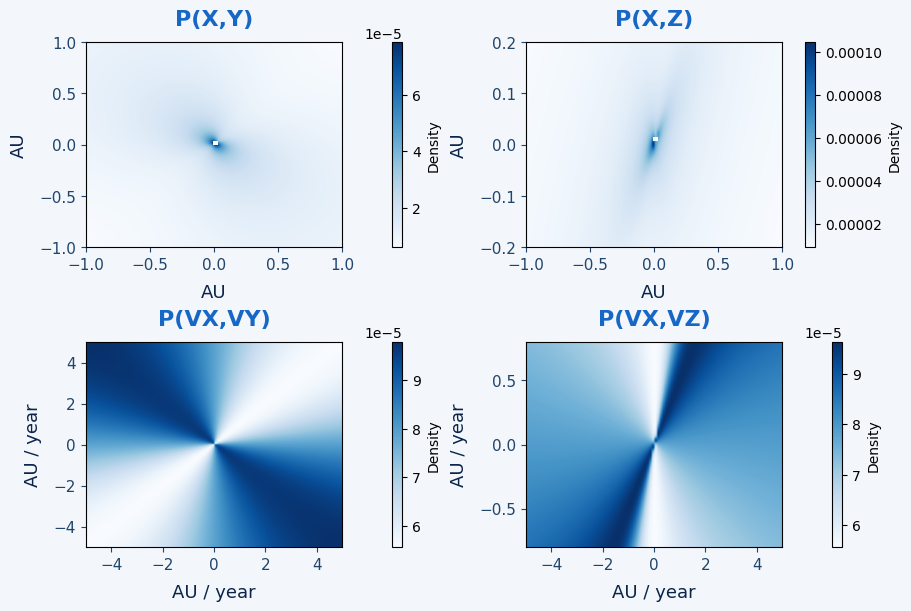

In [156]:
zero_vector = np.zeros_like(X_malla) + 0.01

P_XY, problematic_XY = P_X_vectorized(X_malla, Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_XZ, problematic_XZ = P_X_vectorized(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_VXY, problematic_VXY = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu)
P_VXZ, problematic_VXZ = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu)

plot_configs = [
    {
        "data": P_XY,
        "extent": [xmin, xmax, ymin, ymax],
        "title": "P(X,Y)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_XZ,
        "extent": [xmin, xmax, zmin, zmax],
        "title": "P(X,Z)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_VXY,
        "extent": [vxmin, vxmax, vymin, vymax],
        "title": "P(VX,VY)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    },
    {
        "data": P_VXZ,
        "extent": [vxmin, vxmax, vzmin, vzmax],
        "title": "P(VX,VZ)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    }
]

fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True, facecolor="#f3f6fa")

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        plot_configs[i]["data"],
        origin='lower',
        cmap='Blues',
        interpolation='bilinear',
        extent=plot_configs[i]["extent"],
        aspect='auto'
    )
    ax.set_title(
        plot_configs[i]["title"], 
        fontsize=16, 
        color="#1767c6", 
        pad=12, 
        weight='bold'
    )
    ax.set_xlabel(plot_configs[i]["xlabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.set_ylabel(plot_configs[i]["ylabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=11, colors='#20456c')
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    fig.colorbar(
        im, 
        ax=ax, 
        fraction=0.045, 
        pad=0.04, 
        orientation='vertical', 
        label='Density'
    )
"""
plt.suptitle(
    'Probability Density Function $P(X)$ evaluated at the limits of the distribution state space vectors',
    fontsize=18,
    color='#15335b',
    fontweight='semibold',
    y=1.04
)
"""
plt.show()

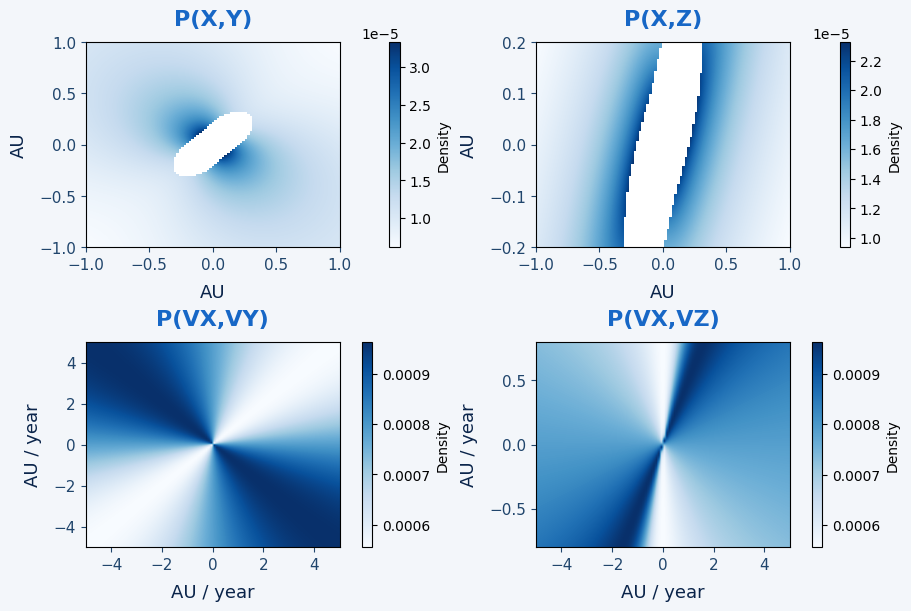

In [157]:
zero_vector = np.zeros_like(X_malla) + 0.0001

P_XY, problematic_XY = P_X_vectorized(X_malla, Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_XZ, problematic_XZ = P_X_vectorized(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu)
P_VXY, problematic_VXY = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu)
P_VXZ, problematic_VXZ = P_X_vectorized(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu)

plot_configs = [
    {
        "data": P_XY,
        "extent": [xmin, xmax, ymin, ymax],
        "title": "P(X,Y)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_XZ,
        "extent": [xmin, xmax, zmin, zmax],
        "title": "P(X,Z)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_VXY,
        "extent": [vxmin, vxmax, vymin, vymax],
        "title": "P(VX,VY)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    },
    {
        "data": P_VXZ,
        "extent": [vxmin, vxmax, vzmin, vzmax],
        "title": "P(VX,VZ)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    }
]

fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True, facecolor="#f3f6fa")

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        plot_configs[i]["data"],
        origin='lower',
        cmap='Blues',
        interpolation='bilinear',
        extent=plot_configs[i]["extent"],
        aspect='auto'
    )
    ax.set_title(
        plot_configs[i]["title"], 
        fontsize=16, 
        color="#1767c6", 
        pad=12, 
        weight='bold'
    )
    ax.set_xlabel(plot_configs[i]["xlabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.set_ylabel(plot_configs[i]["ylabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=11, colors='#20456c')
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    fig.colorbar(
        im, 
        ax=ax, 
        fraction=0.045, 
        pad=0.04, 
        orientation='vertical', 
        label='Density'
    )
"""
plt.suptitle(
    'Probability Density Function $P(X)$ evaluated at the limits of the distribution state space vectors',
    fontsize=18,
    color='#15335b',
    fontweight='semibold',
    y=1.04
)
"""
plt.show()

In [158]:
def P_E_CMND(a: float, e: float, i: float, F: mm.FitCMND) -> float:
    max = 2*np.pi; min = 0

    P_aei = F.cmnd.pdf([a, e, i])
    P_WwM = 1/(max - min)**3

    return P_aei * P_WwM

In [159]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    problematic = []
    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
        with np.errstate(divide='ignore', invalid='ignore'):
            det = np.linalg.det(J)
            #print(x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx])
            #print(det)
            if det == 0 or not np.isfinite(det):
                problematic.append((x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx]))
                P.flat[idx] = np.nan
            else:
                inv_det = 1.0/det  
                P.flat[idx] = P_E_CMND(a, e, i, F) * abs(inv_det)

    return P.reshape(shape), problematic

In [160]:
F = mm.FitCMND(f"../multimin/products/fit-NEOS-Ngauss50.pkl")

xmin, xmax = (0.9039710143502464, 1.0960289856497536)
ymin, ymax = ( -0.09602898564975362, 0.09602898564975362)
zmin, zmax = (-0.09602898564975362, 0.09602898564975362)
vxmin, vxmax = (-0.5064245183055923, 0.5064245183055923)
vymin, vymax = (5.777598212496408, 6.790447249107593)
vzmin, vzmax = (-0.5064245183055923, 0.5064245183055923)


X = np.linspace(xmin, xmax, 100)
Y = np.linspace(ymin, ymax, 100)
Z = np.linspace(zmin, zmax, 100)
VX = np.linspace(vxmin, vxmax, 100)
VY = np.linspace(vymin, vymax, 100)
VZ = np.linspace(vzmin, vzmax, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla) + 0.1

P_XY, problematic_XY = P_X_CMND(X_malla, Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu, F=F)
P_XZ, problematic_XZ = P_X_CMND(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu, F=F)
P_VXY, problematic_VXY = P_X_CMND(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu, F=F)
P_VXZ, problematic_VXZ = P_X_CMND(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu, F=F)

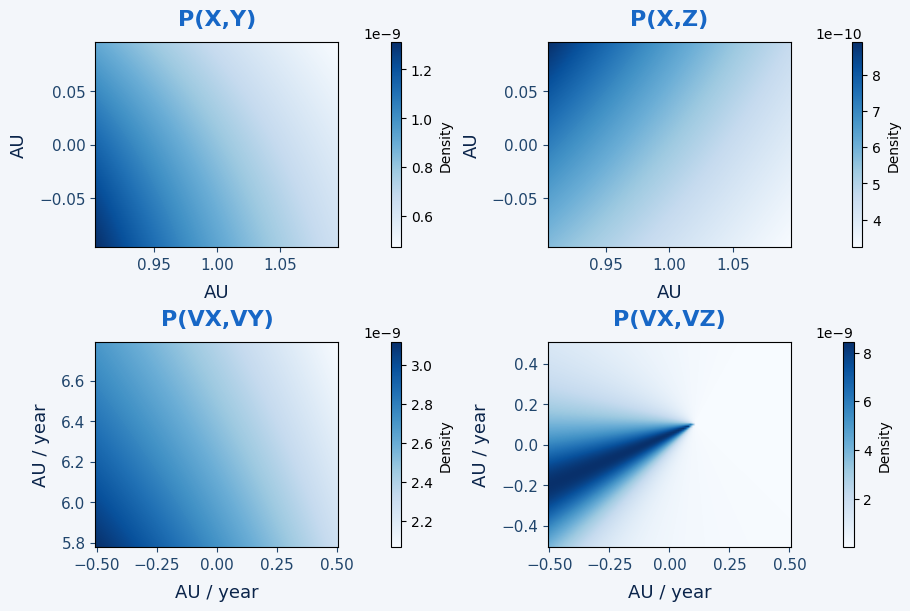

In [161]:
plot_configs = [
    {
        "data": P_XY,
        "extent": [xmin, xmax, ymin, ymax],
        "title": "P(X,Y)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_XZ,
        "extent": [xmin, xmax, zmin, zmax],
        "title": "P(X,Z)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_VXY,
        "extent": [vxmin, vxmax, vymin, vymax],
        "title": "P(VX,VY)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    },
    {
        "data": P_VXZ,
        "extent": [vxmin, vxmax, vzmin, vzmax],
        "title": "P(VX,VZ)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    }
]

# Use 'Blues' colormap and customize plot styling
fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True, facecolor="#f3f6fa")

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        plot_configs[i]["data"],
        origin='lower',
        cmap='Blues',
        interpolation='bilinear',
        extent=plot_configs[i]["extent"],
        aspect='auto'
    )
    ax.set_title(
        plot_configs[i]["title"], 
        fontsize=16, 
        color="#1767c6", 
        pad=12, 
        weight='bold'
    )
    ax.set_xlabel(plot_configs[i]["xlabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.set_ylabel(plot_configs[i]["ylabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=11, colors='#20456c')
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    fig.colorbar(
        im, 
        ax=ax, 
        fraction=0.045, 
        pad=0.04, 
        orientation='vertical', 
        label='Density'
    )
"""
plt.suptitle(
    'Probability Density Function $P(X)$ evaluated at the limits of the distribution state space vectors',
    fontsize=18,
    color='#15335b',
    fontweight='semibold',
    y=1.04
)
"""
plt.show()

In [162]:
xmin, xmax = (-1, 1)
ymin, ymax = ( -1, 1)
zmin, zmax = (-0.2, 0.2)
vxmin, vxmax = (-5, 5)
vymin, vymax = (-5, 5)
vzmin, vzmax = (-0.8, 0.8)

X = np.linspace(xmin, xmax, 100)
Y = np.linspace(ymin, ymax, 100)
Z = np.linspace(zmin, zmax, 100)
VX = np.linspace(vxmin, vxmax, 100)
VY = np.linspace(vymin, vymax, 100)
VZ = np.linspace(vzmin, vzmax, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla) + 0.1

P_XY, problematic_XY = P_X_CMND(X_malla, Y_malla, z=zero_vector, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu, F=F)
P_XZ, problematic_XZ = P_X_CMND(X_malla, y=zero_vector, z=Z_malla, vx=zero_vector, vy=zero_vector, vz=zero_vector, mu=mu, F=F)
P_VXY, problematic_VXY = P_X_CMND(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=VY_malla, vz=zero_vector, mu=mu, F=F)
P_VXZ, problematic_VXZ = P_X_CMND(x=zero_vector, y=zero_vector, z=zero_vector, vx=VX_malla, vy=zero_vector, vz=VZ_malla, mu=mu, F=F)

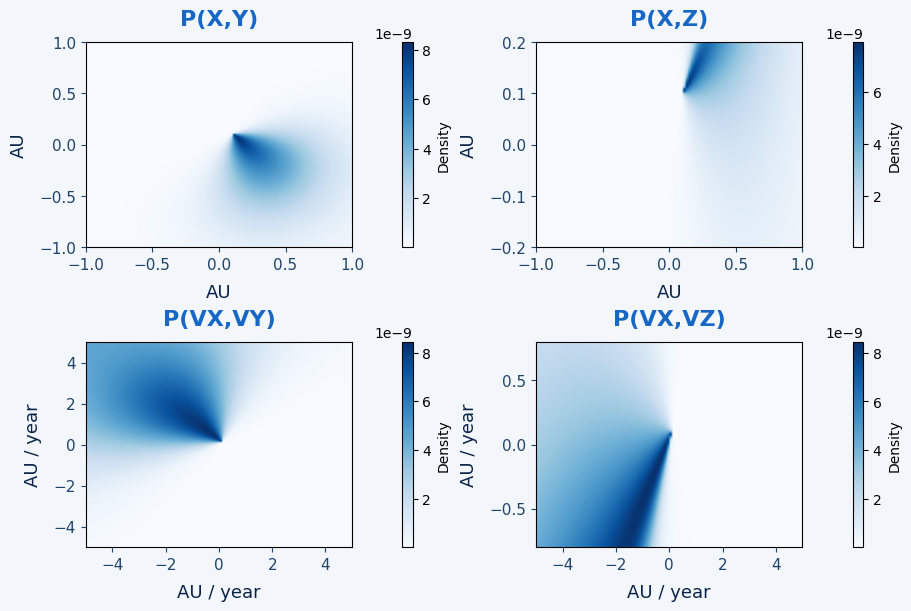

In [163]:
plot_configs = [
    {
        "data": P_XY,
        "extent": [xmin, xmax, ymin, ymax],
        "title": "P(X,Y)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_XZ,
        "extent": [xmin, xmax, zmin, zmax],
        "title": "P(X,Z)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_VXY,
        "extent": [vxmin, vxmax, vymin, vymax],
        "title": "P(VX,VY)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    },
    {
        "data": P_VXZ,
        "extent": [vxmin, vxmax, vzmin, vzmax],
        "title": "P(VX,VZ)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    }
]

# Use 'Blues' colormap and customize plot styling
fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True, facecolor="#f3f6fa")

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        plot_configs[i]["data"],
        origin='lower',
        cmap='Blues',
        interpolation='bilinear',
        extent=plot_configs[i]["extent"],
        aspect='auto'
    )
    ax.set_title(
        plot_configs[i]["title"], 
        fontsize=16, 
        color="#1767c6", 
        pad=12, 
        weight='bold'
    )
    ax.set_xlabel(plot_configs[i]["xlabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.set_ylabel(plot_configs[i]["ylabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=11, colors='#20456c')
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    fig.colorbar(
        im, 
        ax=ax, 
        fraction=0.045, 
        pad=0.04, 
        orientation='vertical', 
        label='Density'
    )
"""
plt.suptitle(
    'Probability Density Function $P(X)$ evaluated at the limits of the distribution state space vectors',
    fontsize=18,
    color='#15335b',
    fontweight='semibold',
    y=1.04
)
"""
plt.show()

### Mapping $P(\widetilde{X})$ with the Jacobian of the Toroid transformation

In [164]:
def calculate_jacobian_torus_to_r3(point, R, r):
    """
    Calculates the Jacobian matrix of the transformation from Torus to R^3 at a given point.
    """
    x, y, z = point
    #R = (a + b) / 2.0
    #r = (b - a) / 2.0

    # Handle singularity at the z-axis
    r_xy = np.sqrt(x**2 + y**2)
    if r_xy < 1e-9: # Avoid division by zero
        # The Jacobian is not well-defined on the z-axis, but we can return a limit
        # For simplicity, we'll state it's undefined for this example.
        print("Warning: Jacobian is not well-defined on the z-axis.")
        return np.full((3, 3), np.nan)

    s = np.sqrt((r_xy - R)**2 + z**2)
    if s < 1e-9: # Avoid division by zero at the central circle
        print("Warning: Jacobian is not well-defined on the central circle.")
        return np.full((3, 3), np.nan)

    # Scaling function and its derivative
    f_s = np.tan((np.pi / 2.0) * (s / r))
    f_prime_s = (np.pi / (2.0 * r)) * (1.0 / np.cos((np.pi / 2.0) * (s / r))**2)

    # Pre-compute common terms
    term1 = (1 - R / r_xy)
    term2 = f_prime_s - f_s / s

    # Initialize Jacobian matrix
    J = np.zeros((3, 3))

    # Partial derivatives (dx'/dx, dx'/dy, dx'/dz)
    J[0, 0] = (R/r_xy) * (y**2/r_xy**2) + (f_s/s)*term1 + (x**2/s**2) * term1**2 * term2
    J[0, 1] = -(R/r_xy) * (x*y/r_xy**2) + (x*y/s**2) * term1**2 * term2
    J[0, 2] = (x*z/s**2) * ((r_xy - R)/r_xy) * term2

    # Partial derivatives (dy'/dx, dy'/dy, dy'/dz)
    J[1, 0] = -(R/r_xy) * (x*y/r_xy**2) + (x*y/s**2) * term1**2 * term2
    J[1, 1] = (R/r_xy) * (x**2/r_xy**2) + (f_s/s)*term1 + (y**2/s**2) * term1**2 * term2
    J[1, 2] = (y*z/s**2) * ((r_xy - R)/r_xy) * term2

    # Partial derivatives (dz'/dx, dz'/dy, dz'/dz)
    J[2, 0] = (x*z/s**2) * ((r_xy - R)/r_xy) * term2
    J[2, 1] = (y*z/s**2) * ((r_xy - R)/r_xy) * term2
    J[2, 2] = (f_s/s) + (z**2/s**2) * term2
    
    return J

In [165]:
def P_X_prime(x: np.array, y: np.array, z: np.array, vx_prime: np.array, vy_prime: np.array, vz_prime: np.array, mu: float, R: float, r: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx_prime)
    vy = np.asarray(vy_prime)
    vz = np.asarray(vz_prime)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    problematic = []
    for idx in range(x_flat.size):
        a, e, i, Omega, w, M = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        J_XoE = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
        J_VoV_prime = calculate_jacobian_torus_to_r3([vx_flat[idx], vy_flat[idx], vz_flat[idx]], R, r)
        with np.errstate(divide='ignore', invalid='ignore'):
            det_XoE = np.linalg.det(J_XoE) 
            det_VoV_prime = np.linalg.det(J_VoV_prime)
            #print(x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx])
            #print(det)
            if det_XoE == 0 or not np.isfinite(det_XoE):
                problematic.append((x_flat[idx], y_flat[idx], z_flat[idx],  vx_flat[idx], vy_flat[idx], vz_flat[idx]))
                P.flat[idx] = np.nan
            else:
                inv_det_XoE = 1.0/det_XoE
                det = det_VoV_prime * inv_det_XoE
                P.flat[idx] = P_E() * abs(det)

    return P.reshape(shape), problematic


In [166]:
R = 5.5044 #with 99% of objects inside the toroid 
r = 3.6063 #with 99% of objects inside the toroid 

xmin, xmax = (0.9039710143502464, 1.0960289856497536)
ymin, ymax = ( -0.09602898564975362, 0.09602898564975362)
zmin, zmax = (-0.09602898564975362, 0.09602898564975362)
vxmin, vxmax = (-0.5064245183055923, 0.5064245183055923)
vymin, vymax = (5.777598212496408, 6.790447249107593)
vzmin, vzmax = (-0.5064245183055923, 0.5064245183055923)


X = np.linspace(xmin, xmax, 100)
Y = np.linspace(ymin, ymax, 100)
Z = np.linspace(zmin, zmax, 100)
VX = np.linspace(vxmin, vxmax, 100)
VY = np.linspace(vymin, vymax, 100)
VZ = np.linspace(vzmin, vzmax, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
X_malla, Z_malla = np.meshgrid(X, Z)
VX_malla, VY_malla = np.meshgrid(VX, VY)
VX_malla, VZ_malla = np.meshgrid(VX, VZ)

zero_vector = np.zeros_like(X_malla) + 0.1

P_XY, problematic_XY = P_X_prime(X_malla, Y_malla, z=zero_vector, vx_prime=zero_vector, vy_prime=zero_vector, vz_prime=zero_vector, mu=mu, R=R, r=r)
P_XZ, problematic_XZ = P_X_prime(X_malla, y=zero_vector, z=Z_malla, vx_prime=zero_vector, vy_prime=zero_vector, vz_prime=zero_vector, mu=mu, R=R, r=r)
P_VXY, problematic_VXY = P_X_prime(x=zero_vector, y=zero_vector, z=zero_vector, vx_prime=VX_malla, vy_prime=VY_malla, vz_prime=zero_vector, mu=mu, R=R, r=r)
P_VXZ, problematic_VXZ = P_X_prime(x=zero_vector, y=zero_vector, z=zero_vector, vx_prime=VX_malla, vy_prime=zero_vector, vz_prime=VZ_malla, mu=mu, R=R, r=r)

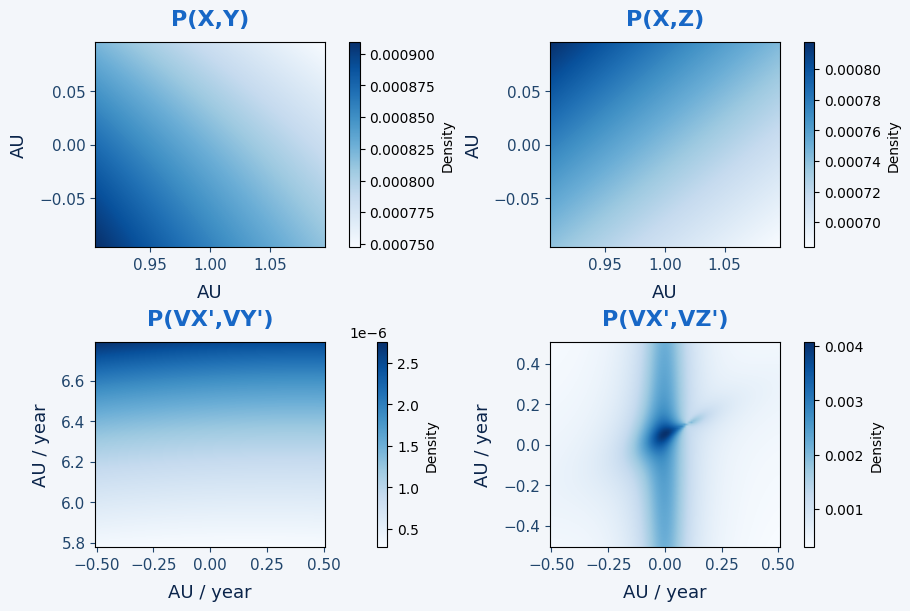

In [167]:
import matplotlib.ticker as mticker

plot_configs = [
    {
        "data": P_XY,
        "extent": [xmin, xmax, ymin, ymax],
        "title": "P(X,Y)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_XZ,
        "extent": [xmin, xmax, zmin, zmax],
        "title": "P(X,Z)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_VXY,
        "extent": [vxmin, vxmax, vymin, vymax],
        "title": "P(VX',VY')",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    },
    {
        "data": P_VXZ,
        "extent": [vxmin, vxmax, vzmin, vzmax],
        "title": "P(VX',VZ')",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    }
]

# Use 'Blues' colormap and customize plot styling
fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True, facecolor="#f3f6fa")

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        plot_configs[i]["data"],
        origin='lower',
        cmap='Blues',
        interpolation='bilinear',
        extent=plot_configs[i]["extent"],
        aspect='auto'
    )
    ax.set_title(
        plot_configs[i]["title"], 
        fontsize=16, 
        color="#1767c6", 
        pad=12, 
        weight='bold'
    )
    ax.set_xlabel(plot_configs[i]["xlabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.set_ylabel(plot_configs[i]["ylabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=11, colors='#20456c')
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    fig.colorbar(
        im, 
        ax=ax, 
        fraction=0.045, 
        pad=0.04, 
        orientation='vertical', 
        label='Density'
    )
"""
plt.suptitle(
    'Probability Density Function $P(X)$ evaluated at the limits of the distribution state space vectors',
    fontsize=18,
    color='#15335b',
    fontweight='semibold',
    y=1.04
)
"""
plt.show()

### Mapping Jacobian of the trasformation (a,e,w,M) -> (x,y,vx,vy)

In [168]:
from Utils import P_xyvxvy_vectorized 

xmin, xmax = (0.9039710143502464, 1.0960289856497536)
ymin, ymax = ( -0.09602898564975362, 0.09602898564975362)
vxmin, vxmax = (-0.5064245183055923, 0.5064245183055923)
vymin, vymax = (5.777598212496408, 6.790447249107593)

X = np.linspace(xmin, xmax, 100)
Y = np.linspace(ymin, ymax, 100)
VX = np.linspace(vxmin, vxmax, 100)
VY = np.linspace(vymin, vymax, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
VX_malla, VY_malla = np.meshgrid(VX, VY)

zero_vector = np.zeros_like(X_malla) + 0.1

P_XY = P_xyvxvy_vectorized(X_malla, Y_malla, vx=zero_vector, vy=zero_vector, mu=mu)
P_VXY = P_xyvxvy_vectorized(x=zero_vector, y=zero_vector, vx=VX_malla, vy=VY_malla, mu=mu)

In [169]:
P_XY

array([[1.51431905e-05, 1.51564981e-05, 1.51697941e-05, ...,
        1.63842944e-05, 1.63966050e-05, 1.64089064e-05],
       [1.51154848e-05, 1.51288179e-05, 1.51421393e-05, ...,
        1.63587819e-05, 1.63711126e-05, 1.63834341e-05],
       [1.50877392e-05, 1.51010979e-05, 1.51144448e-05, ...,
        1.63332404e-05, 1.63455912e-05, 1.63579327e-05],
       ...,
       [1.22951254e-05, 1.23114417e-05, 1.23277369e-05, ...,
        1.37902117e-05, 1.38047990e-05, 1.38193713e-05],
       [1.22643912e-05, 1.22807425e-05, 1.22970727e-05, ...,
        1.37624112e-05, 1.37770246e-05, 1.37916229e-05],
       [1.22336364e-05, 1.22500227e-05, 1.22663878e-05, ...,
        1.37345936e-05, 1.37492332e-05, 1.37638575e-05]])

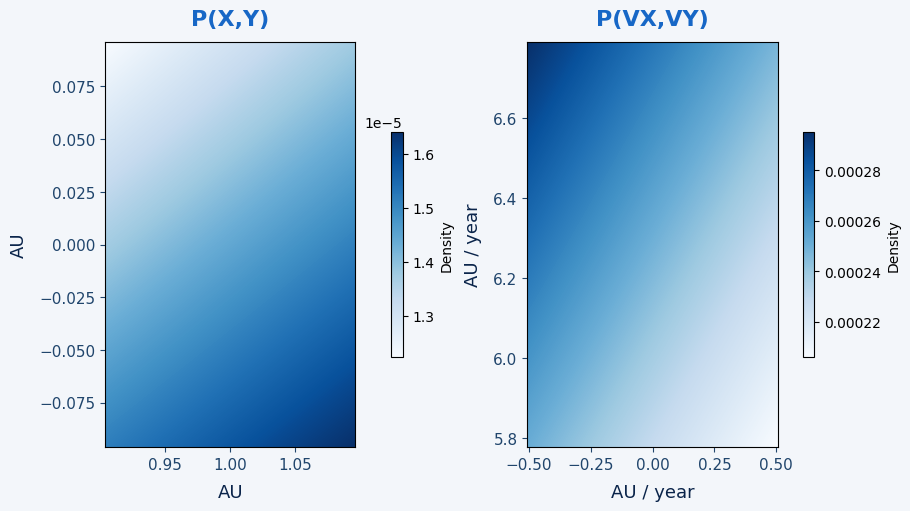

In [170]:
import matplotlib.ticker as mticker

plot_configs = [
    {
        "data": P_XY,
        "extent": [xmin, xmax, ymin, ymax],
        "title": "P(X,Y)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_VXY,
        "extent": [vxmin, vxmax, vymin, vymax],
        "title": "P(VX,VY)",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    }
]

# Use 'Blues' colormap and customize plot styling
fig, axes = plt.subplots(1, 2, figsize=(9, 5), constrained_layout=True, facecolor="#f3f6fa")

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        plot_configs[i]["data"],
        origin='lower',
        cmap='Blues',
        interpolation='bilinear',
        extent=plot_configs[i]["extent"],
        aspect='auto'
    )
    ax.set_title(
        plot_configs[i]["title"], 
        fontsize=16, 
        color="#1767c6", 
        pad=12, 
        weight='bold'
    )
    ax.set_xlabel(plot_configs[i]["xlabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.set_ylabel(plot_configs[i]["ylabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=11, colors='#20456c')
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    fig.colorbar(
        im, 
        ax=ax, 
        fraction=0.045, 
        pad=0.04, 
        orientation='vertical', 
        label='Density'
    )
"""
plt.suptitle(
    'Probability Density Function $P(X)$ evaluated at the limits of the distribution state space vectors',
    fontsize=18,
    color='#15335b',
    fontweight='semibold',
    y=1.04
)
"""
plt.show()

### Mapping $P(\widetilde{X})$ with the Jacobian of the Annulus transformation

In [171]:
def calculate_jacobian_annulus_to_r2(x, y, r, R):
    """
    Calculates the Jacobian matrix for the transformation from an annulus to R^2.

    Args:
        x: The x-coordinate of the point in the annulus.
        y: The y-coordinate of the point in the annulus.
        r: The minor radius of the annulus.
        R: The major radius of the annulus.

    Returns:
        A 2x2 NumPy array representing the Jacobian matrix.
    """
    # Calculate rho and theta
    rho = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)

    # Intermediate variables u and v
    u = (rho - r) / (R - r)
    v = theta / (2 * np.pi)

    # Clip u and v to avoid singularities
    epsilon = 1e-9
    u = np.clip(u, epsilon, 1 - epsilon)
    v = np.clip(v, epsilon, 1 - epsilon)

    # Calculate A and B (common terms in the Jacobian)
    A = 1 / np.cos(np.pi * (u - 0.5))**2  # sec^2
    B = 1 / np.cos(np.pi * (v - 0.5))**2  # sec^2

    # Calculate partial derivatives
    dxprime_dx = (np.pi * x * A) / ((R - r) * rho)
    dxprime_dy = (np.pi * y * A) / ((R - r) * rho)
    dyprime_dx = (-y * B) / (2 * (x**2 + y**2))
    dyprime_dy = (x * B) / (2 * (x**2 + y**2))

    # Create the Jacobian matrix
    jacobian = np.array([[dxprime_dx, dxprime_dy],
                         [dyprime_dx, dyprime_dy]])

    return jacobian

In [172]:
from Utils import trasformation_xyvxvy_to_aewE, jacobian_xyvxvytoaewM, P_aewM

def P_xyvxvy_prime(x: np.array, y: np.array, vx: np.array, vy: np.array, r: float, R: float, mu: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    vx = np.asarray(vx)
    vy = np.asarray(vy)

    # Prepare output array
    shape = np.broadcast(x, y, vx, vy).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()

    for idx in range(x_flat.size):
        a, e, w, M = trasformation_xyvxvy_to_aewE(x_flat[idx], y_flat[idx], vx_flat[idx], vy_flat[idx], mu)
        J_xyvxvy = jacobian_xyvxvytoaewM(a,e,w,M,mu)
        J_annulus = calculate_jacobian_annulus_to_r2(vx_flat[idx], vy_flat[idx], r, R)
        det = (1.0/np.linalg.det(J_xyvxvy)) * np.linalg.det(J_annulus)
        #det = np.linalg.det(J)/(1-e)
        P.flat[idx] = P_aewM() * abs(det)

    return P.reshape(shape)

In [173]:
from Utils import trasformation_xyvxvy_to_aewE, jacobian_xyvxvytoaewM, P_aewM

r = 1.9833
R = 8.0243

xmin, xmax = (0.9039710143502464, 1.0960289856497536)
ymin, ymax = ( -0.09602898564975362, 0.09602898564975362)
vxmin, vxmax = (-0.5064245183055923, 0.5064245183055923)
vymin, vymax = (5.777598212496408, 6.790447249107593)

X = np.linspace(xmin, xmax, 100)
Y = np.linspace(ymin, ymax, 100)
VX = np.linspace(vxmin, vxmax, 100)
VY = np.linspace(vymin, vymax, 100)

X_malla, Y_malla = np.meshgrid(X, Y)
VX_malla, VY_malla = np.meshgrid(VX, VY)

zero_vector = np.zeros_like(X_malla) + 0.1

P_XY = P_xyvxvy_prime(X_malla, Y_malla, vx=zero_vector, vy=zero_vector, r=r, R=R, mu=mu)
P_VXY = P_xyvxvy_prime(x=zero_vector, y=zero_vector, vx=VX_malla, vy=VY_malla, r=r, R=R, mu=mu)

In [174]:
P_XY

array([[1.92634608e+13, 1.92803893e+13, 1.92973030e+13, ...,
        2.08422534e+13, 2.08579136e+13, 2.08735621e+13],
       [1.92282168e+13, 1.92451776e+13, 1.92621237e+13, ...,
        2.08097994e+13, 2.08254851e+13, 2.08411590e+13],
       [1.91929220e+13, 1.92099154e+13, 1.92268939e+13, ...,
        2.07773082e+13, 2.07930195e+13, 2.08087191e+13],
       ...,
       [1.56404733e+13, 1.56612291e+13, 1.56819581e+13, ...,
        1.75423536e+13, 1.75609100e+13, 1.75794472e+13],
       [1.56013767e+13, 1.56221770e+13, 1.56429504e+13, ...,
        1.75069890e+13, 1.75255786e+13, 1.75441488e+13],
       [1.55622539e+13, 1.55830988e+13, 1.56039167e+13, ...,
        1.74716027e+13, 1.74902254e+13, 1.75088288e+13]])

In [175]:
P_VXY

array([[2.47065667e-05, 2.46940411e-05, 2.46816840e-05, ...,
        2.41467800e-05, 2.41470895e-05, 2.41475175e-05],
       [2.48259907e-05, 2.48132553e-05, 2.48006922e-05, ...,
        2.42622687e-05, 2.42627063e-05, 2.42632660e-05],
       [2.49476756e-05, 2.49347277e-05, 2.49219558e-05, ...,
        2.43799538e-05, 2.43805210e-05, 2.43812138e-05],
       ...,
       [5.84515354e-05, 5.83794964e-05, 5.83087504e-05, ...,
        5.68206012e-05, 5.68576332e-05, 5.68958047e-05],
       [5.92992048e-05, 5.92254775e-05, 5.91530765e-05, ...,
        5.76409335e-05, 5.76790670e-05, 5.77183700e-05],
       [6.01687504e-05, 6.00932806e-05, 6.00191716e-05, ...,
        5.84824060e-05, 5.85216789e-05, 5.85621527e-05]])

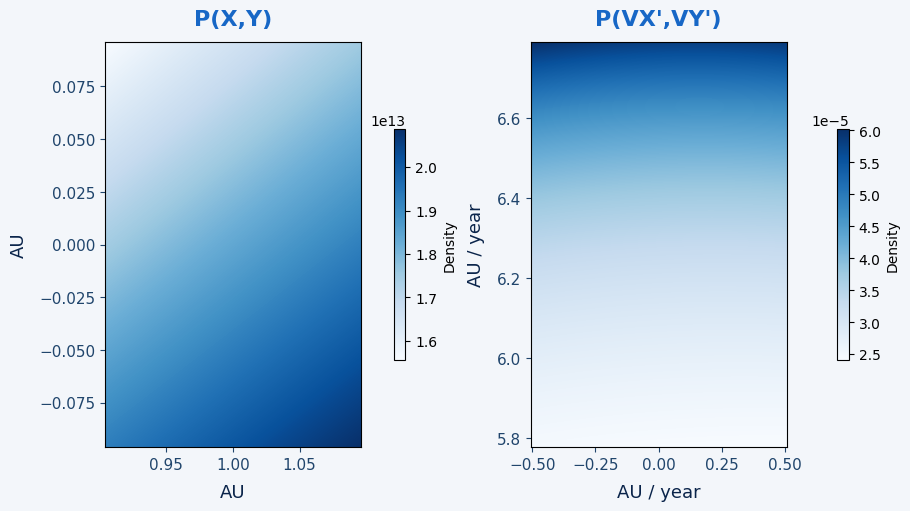

In [176]:
plot_configs = [
    {
        "data": P_XY,
        "extent": [xmin, xmax, ymin, ymax],
        "title": "P(X,Y)",
        "xlabel": "AU",
        "ylabel": "AU"
    },
    {
        "data": P_VXY,
        "extent": [vxmin, vxmax, vymin, vymax],
        "title": "P(VX',VY')",
        "xlabel": "AU / year",
        "ylabel": "AU / year"
    }
]

# Use 'Blues' colormap and customize plot styling
fig, axes = plt.subplots(1, 2, figsize=(9, 5), constrained_layout=True, facecolor="#f3f6fa")

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        plot_configs[i]["data"],
        origin='lower',
        cmap='Blues',
        interpolation='bilinear',
        extent=plot_configs[i]["extent"],
        aspect='auto'
    )
    ax.set_title(
        plot_configs[i]["title"], 
        fontsize=16, 
        color="#1767c6", 
        pad=12, 
        weight='bold'
    )
    ax.set_xlabel(plot_configs[i]["xlabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.set_ylabel(plot_configs[i]["ylabel"], fontsize=13, color="#0a244a", labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=11, colors='#20456c')
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    fig.colorbar(
        im, 
        ax=ax, 
        fraction=0.045, 
        pad=0.04, 
        orientation='vertical', 
        label='Density'
    )
"""
plt.suptitle(
    'Probability Density Function $P(X)$ evaluated at the limits of the distribution state space vectors',
    fontsize=18,
    color='#15335b',
    fontweight='semibold',
    y=1.04
)
"""
plt.show()